# Olist E-Commerce Marketplace Analytics

## Project Objective

This project analyzes the performance of the Olist Brazilian e-commerce marketplace using order, delivery, product, seller, payment, and customer review data.

The main objectives are to:

- Understand marketplace performance over time
- Analyze delivery performance and its relationship with customer satisfaction
- Identify seller and geographic patterns
- Compare product category performance
- Analyze payment methods and installment behavior
- Identify the key factors associated with low customer review scores

## Key Business Question

**What factors are most strongly associated with customer dissatisfaction, and where can the marketplace improve its customer experience?**

## 1. Data Understanding

The dataset contains multiple interconnected tables covering:

- Orders and order status
- Order items, prices, and freight
- Customer reviews and review scores
- Customer information
- Product categories and product attributes
- Seller information and location
- Payment methods and installments
- Geolocation data
- English product category translations

The analysis uses these datasets together to understand marketplace performance, delivery experience, product performance, seller patterns, payment behavior, and customer satisfaction.

In [130]:
import pandas as pd

In [131]:
pd.read_excel("/content/Document from singhlink4.xlsx")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [132]:
import pandas as pd


In [133]:
file_path = "/content/Document from singhlink4.xlsx"

In [134]:
excel_file = pd.ExcelFile(file_path)

In [135]:
print(excel_file.sheet_names)

['orders', 'order_items', 'order_payments', 'order_reviews', 'customers', 'products', 'sellers', 'geolocation', 'category_translation']


In [136]:
orders = pd.read_excel(file_path, sheet_name="orders")

In [137]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [138]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [139]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [140]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [141]:
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [142]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(6)
memory usage: 6.1+ MB


In [143]:
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [144]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [145]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [146]:
orders['order_status'].value_counts(normalize=True) * 100

,proportion
order_status,
delivered,97.020344
shipped,1.113223
canceled,0.628513
unavailable,0.612423
invoiced,0.315765
processing,0.302692
created,0.005028
approved,0.002011


In [147]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

In [148]:
delivered_orders.shape

(96478, 8)

In [149]:
delivered_orders['order_delivered_customer_date'].isna().sum()

np.int64(8)

In [150]:
delivered_orders = delivered_orders.dropna(
    subset=['order_delivered_customer_date']
)

In [151]:
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.days

In [152]:
delivered_orders['delivery_days'].describe()

,delivery_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [153]:
delivered_orders['delivery_delay_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_estimated_delivery_date']
).dt.days

In [154]:
delivered_orders['delivery_delay_days'].describe()

,delivery_delay_days
count,96470.000000
mean,-11.875889
std,10.182105
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [155]:
late_orders = (delivered_orders['delivery_delay_days'] > 0).sum()

late_orders

np.int64(6534)

In [156]:
late_percentage = (
    late_orders / len(delivered_orders)
) * 100

late_percentage

np.float64(6.7730900798175595)

In [157]:
delivery_status = delivered_orders['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time / Early'
)

delivery_status.value_counts(normalize=True) * 100

,proportion
delivery_delay_days,
On Time / Early,93.22691
Late,6.77309


In [158]:
reviews = pd.read_excel(
    file_path,
    sheet_name="order_reviews"
)

In [159]:
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [160]:
reviews['review_score'].isna().sum()

np.int64(0)

In [161]:
reviews['review_score'].value_counts().sort_index()

,count
review_score,
1,11858
2,3235
3,8287
4,19200
5,57420


In [162]:
reviews['review_score'].value_counts(normalize=True).sort_index() * 100

,proportion
review_score,
1,11.858
2,3.235
3,8.287
4,19.200
5,57.420


In [163]:
delivery_reviews = delivered_orders.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

In [164]:
delivery_reviews.shape, delivery_reviews['review_score'].isna().sum()


((97007, 11), np.int64(0))

In [165]:
reviews['order_id'].duplicated().sum()

np.int64(559)

In [166]:
review_counts = reviews.groupby('order_id').size()

review_counts.value_counts().sort_index()

,count
1,98886
2,551
3,4


In [167]:
reviews_clean = (
    reviews.groupby('order_id', as_index=False)['review_score']
    .mean()
)

In [168]:
delivery_reviews = delivered_orders.merge(
    reviews_clean,
    on='order_id',
    how='left'
)

In [169]:
delivery_reviews.shape, delivery_reviews['order_id'].duplicated().sum(), delivery_reviews['review_score'].isna().sum()

((96470, 11), np.int64(0), np.int64(0))

In [170]:
delivery_reviews.groupby(
    delivery_reviews['delivery_delay_days'] > 0
)['review_score'].mean()

,review_score
delivery_delay_days,
False,4.279729
True,2.256581


In [171]:
delivery_reviews['delay_group'] = pd.cut(
    delivery_reviews['delivery_delay_days'],
    bins=[-float('inf'), 0, 3, 7, 14, float('inf')],
    labels=[
        'On Time / Early',
        '1–3 days late',
        '4–7 days late',
        '8–14 days late',
        '15+ days late'
    ]
)

In [172]:
delivery_reviews.groupby('delay_group', observed=True)['review_score'].mean()

,review_score
delay_group,
On Time / Early,4.279729
1–3 days late,3.281818
4–7 days late,2.089068
8–14 days late,1.666441
15+ days late,1.719653


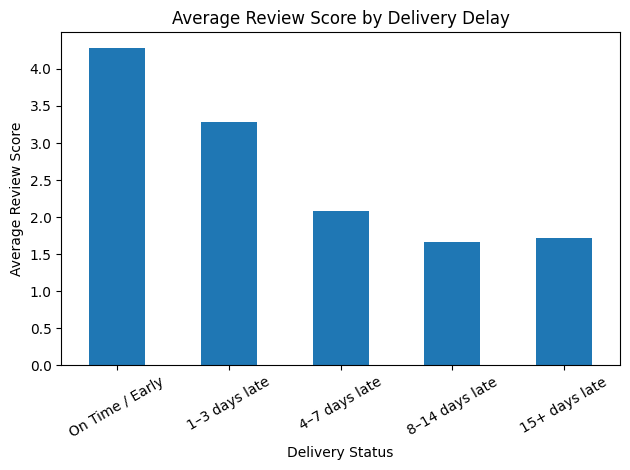

In [173]:
import matplotlib.pyplot as plt

delay_review = delivery_reviews.groupby(
    'delay_group', observed=True
)['review_score'].mean()

delay_review.plot(kind='bar')

plt.title('Average Review Score by Delivery Delay')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [174]:
delivery_reviews['delay_group'].value_counts().sort_index()

,count
delay_group,
On Time / Early,89936
1–3 days late,1870
4–7 days late,1802
8–14 days late,1478
15+ days late,1384


In [175]:
products = pd.read_excel(
    file_path,
    sheet_name="products"
)

In [176]:
products.columns


Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [177]:
products['product_category_name'].isna().sum()


np.int64(610)

In [178]:
category_translation = pd.read_excel(
    file_path,
    sheet_name="category_translation"
)

In [179]:
category_translation.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [180]:
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [181]:
products['product_category_name_english'].isna().sum()

np.int64(623)

In [182]:
products['product_category_name'].isna().sum()

np.int64(610)

In [183]:
products['product_category_name'].nunique()

73

In [184]:
order_items = pd.read_excel(
    file_path,
    sheet_name="order_items"
)

In [185]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'price',
       'freight_value'],
      dtype='object')

In [186]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       112650 non-null  object 
 1   order_item_id  112650 non-null  int64  
 2   product_id     112650 non-null  object 
 3   seller_id      112650 non-null  object 
 4   price          112650 non-null  float64
 5   freight_value  112650 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 5.2+ MB


In [187]:
items_products = order_items.merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

In [188]:
items_products['product_category_name_english'].isna().sum()

np.int64(1627)

In [189]:
items_products['product_category_name_english'] = (
    items_products['product_category_name_english']
    .fillna('Unknown')
)

In [190]:
category_item_count = (
    items_products['product_category_name_english']
    .value_counts()
)

category_item_count.head(10)

,count
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347


In [191]:
category_avg_price = (
    items_products.groupby('product_category_name_english')['price']
    .mean()
    .sort_values(ascending=False)
)

category_avg_price.head(10)

,price
product_category_name_english,
computers,1098.340542
small_appliances_home_oven_and_coffee,624.285658
home_appliances_2,476.124958
agro_industry_and_commerce,342.124858
musical_instruments,281.616000
small_appliances,280.778468
fixed_telephony,225.693182
construction_tools_safety,208.992371
watches_gifts,201.135984


In [192]:
category_review = (
    items_products.merge(
        reviews_clean,
        on='order_id',
        how='left'
    )
    .groupby('product_category_name_english')['review_score']
    .mean()
    .sort_values(ascending=False)
)

category_review.head(10)

,review_score
product_category_name_english,
cds_dvds_musicals,4.642857
fashion_childrens_clothes,4.500000
books_general_interest,4.439421
books_imported,4.400000
costruction_tools_tools,4.359223
books_technical,4.333333
luggage_accessories,4.309524
small_appliances_home_oven_and_coffee,4.302632
food_drink,4.300360


In [193]:
category_sales = (
    items_products.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
)

category_sales.head(10)

,price
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


In [194]:
category_summary = pd.concat(
    [
        category_item_count.rename('item_count'),
        category_sales.rename('sales_value'),
        category_review.rename('avg_review_score')
    ],
    axis=1
).sort_values('sales_value', ascending=False)

category_summary.head(10)

,item_count,sales_value,avg_review_score
product_category_name_english,,,
health_beauty,9670,1258681.34,4.123354
watches_gifts,5991,1205005.68,4.001669
bed_bath_table,11115,1036988.68,3.873729
sports_leisure,8641,988048.97,4.092293
computers_accessories,7827,911954.32,3.922256
furniture_decor,8334,729762.49,3.891049
cool_stuff,3796,635290.85,4.131586
housewares,6964,632248.66,4.039632
auto,4235,592720.11,4.038961


In [195]:
category_summary.sort_values(
    'avg_review_score',
    ascending=True
).head(10)

,item_count,sales_value,avg_review_score
product_category_name_english,,,
security_and_services,2,283.29,2.500000
diapers_and_hygiene,39,1567.59,3.256410
home_comfort_2,30,760.27,3.366667
office_furniture,1691,273960.70,3.480189
fashion_male_clothing,132,10797.82,3.621212
fixed_telephony,264,59583.00,3.670455
party_supplies,43,4485.18,3.767442
fashio_female_clothing,48,2803.64,3.781250
la_cuisine,14,2054.99,3.785714


In [196]:
category_summary[
    category_summary['item_count'] >= 500
].sort_values(
    'avg_review_score',
    ascending=True
).head(10)

,item_count,sales_value,avg_review_score
product_category_name_english,,,
office_furniture,1691,273960.70,3.480189
Unknown,1627,185049.76,3.812846
bed_bath_table,11115,1036988.68,3.873729
furniture_living_room,503,68916.56,3.882704
furniture_decor,8334,729762.49,3.891049
computers_accessories,7827,911954.32,3.922256
home_construction,604,83088.12,3.927152
telephony,4545,323667.53,3.934653
baby,3065,411764.89,3.994617


In [197]:
order_payments = pd.read_excel(
    file_path,
    sheet_name="order_payments"
)

order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [198]:
order_payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [199]:
order_payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)


,payment_value
payment_type,
credit_card,163.319021
boleto,145.034435
debit_card,142.570170
voucher,65.703354
not_defined,0.000000


In [200]:
payment_reviews = order_payments.merge(
    reviews_clean,
    on='order_id',
    how='left'
)

payment_reviews.groupby('payment_type')['review_score'].mean().sort_values()

,review_score
payment_type,
not_defined,1.666667
voucher,3.993045
boleto,4.071927
credit_card,4.072372
debit_card,4.158600


In [201]:
payment_reviews.groupby('payment_installments')['review_score'].mean().sort_index()

,review_score
payment_installments,
0,5.000000
1,4.096855
2,4.093732
3,4.039480
4,4.040833
5,4.046765
6,4.060714
7,4.016605
8,4.007381


In [202]:
payment_reviews['installment_group'] = pd.cut(
    payment_reviews['payment_installments'],
    bins=[-1, 1, 3, 6, float('inf')],
    labels=[
        '1 installment',
        '2–3 installments',
        '4–6 installments',
        '7+ installments'
    ]
)

payment_reviews.groupby(
    'installment_group',
    observed=True
)['review_score'].mean()

,review_score
installment_group,
1 installment,4.096889
2–3 installments,4.068921
4–6 installments,4.047538
7+ installments,3.978332


In [203]:
payment_reviews.groupby(
    'installment_group',
    observed=True
)['payment_value'].mean()

,payment_value
installment_group,
1 installment,112.419540
2–3 installments,134.230429
4–6 installments,181.318430
7+ installments,334.510492


In [204]:
delivery_reviews['low_review'] = (
    delivery_reviews['review_score'] <= 2
)

delivery_reviews['low_review'].value_counts()

,count
low_review,
False,83816
True,12654


In [205]:
delivery_reviews.groupby('low_review')['delivery_delay_days'].mean()

,delivery_delay_days
low_review,
False,-12.902859
True,-5.073574


In [206]:
delivery_reviews.groupby(
    delivery_reviews['delivery_delay_days'] > 0
)['low_review'].mean() * 100

,low_review
delivery_delay_days,
False,9.506760
True,62.809917


In [207]:
delivery_reviews.groupby(
    'delay_group',
    observed=True
)['low_review'].mean().mul(100)

,low_review
delay_group,
On Time / Early,9.506760
1–3 days late,32.459893
4–7 days late,67.980022
8–14 days late,80.311231
15+ days late,78.395954


In [208]:
items_reviews = items_products.merge(
    reviews_clean,
    on='order_id',
    how='left'
)

items_reviews['low_review'] = items_reviews['review_score'] <= 2

items_reviews.groupby('low_review')['freight_value'].mean()

,freight_value
low_review,
False,19.759452
True,21.158593


In [209]:
items_reviews.groupby('low_review')['price'].mean()


,price
low_review,
False,119.697482
True,125.492744


In [210]:
items_reviews.groupby(
    'product_category_name_english'
)['low_review'].mean().mul(100).sort_values(
    ascending=False
).head(10)

,low_review
product_category_name_english,
security_and_services,50.000000
home_comfort_2,33.333333
fashion_male_clothing,28.787879
la_cuisine,28.571429
office_furniture,26.315789
fixed_telephony,26.136364
diapers_and_hygiene,25.641026
party_supplies,23.255814
Unknown,22.741242


In [211]:
payment_reviews['low_review'] = (
    payment_reviews['review_score'] <= 2
)

payment_reviews.groupby(
    'payment_type'
)['low_review'].mean().mul(100).sort_values(ascending=False)

,low_review
payment_type,
not_defined,66.666667
voucher,17.194805
credit_card,15.062179
boleto,14.809947
debit_card,13.276651


In [212]:
sellers = pd.read_excel(
    file_path,
    sheet_name="sellers"
)

sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [213]:
items_sellers = order_items.merge(
    sellers,
    on='seller_id',
    how='left'
)

items_sellers.head()

,order_id,order_item_id,product_id,seller_id,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,87900,loanda,PR


In [214]:
seller_summary = (
    items_sellers.groupby(
        ['seller_id', 'seller_city', 'seller_state']
    )
    .agg(
        item_count=('order_id', 'count'),
        sales_value=('price', 'sum'),
        avg_freight=('freight_value', 'mean')
    )
    .sort_values('sales_value', ascending=False)
)

seller_summary.head(10)

,,,item_count,sales_value,avg_freight
seller_id,seller_city,seller_state,,,
4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1156,229472.63,17.446427
53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,410,222776.05,31.903976
4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1987,200472.92,17.648234
fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,586,194042.03,17.137713
7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,1364,187923.89,37.839113
7e93a43ef30c4f03f38b393420bc753a,barueri,SP,340,176431.87,18.594647
da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1551,160236.57,16.090103
7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1171,141745.53,17.850427
1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,1428,138968.55,23.733992


In [215]:
seller_reviews = items_sellers.merge(
    reviews_clean,
    on='order_id',
    how='left'
)

seller_reviews['low_review'] = (
    seller_reviews['review_score'] <= 2
)

seller_reviews.groupby('seller_id')['review_score'].mean().sort_values().head(10)

,review_score
seller_id,
20f0aeea30bc3b8c4420be8ced4226c0,1.0
010da0602d7774602cd1b3f5fb7b709e,1.0
20fd2d2080ed85fa67fad3fcbb2c1813,1.0
ffcfefa19b08742c5d315f2791395ee5,1.0
88af55b4a7ca402b27df16f7c7c9b5d2,1.0
001e6ad469a905060d959994f1b41e4f,1.0
87f3e35268860433e13d577825aada95,1.0
880eda903e719a5f179f7e9fceb3a69d,1.0
6e2d3e2dc84fb30f6078f39dd3bddd6f,1.0


In [216]:
seller_performance = (
    seller_reviews.groupby(
        ['seller_id', 'seller_city', 'seller_state']
    )
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
)

seller_performance = seller_performance[
    seller_performance['item_count'] >= 50
].sort_values('avg_review_score')

seller_performance.head(10)

,,,item_count,avg_review_score,low_review_rate
seller_id,seller_city,seller_state,,,
1ca7077d890b907f89be8c954a02686a,santana de parnaiba,SP,137,2.189781,0.656934
2eb70248d66e0e3ef83659f71b244378,campinas,SP,212,2.681604,0.509434
54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,86,2.825581,0.488372
972d0f9cf61b499a4812cf0bfa3ad3c4,brusque,SC,88,2.920455,0.454545
602044f2c16190c2c6e45eb35c2e21cb,ibitinga,SP,57,2.929825,0.438596
a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,106,2.952830,0.433962
2a1348e9addc1af5aaa619b1a3679d6b,belo horizonte,MG,55,2.963636,0.418182
8e6d7754bc7e0f22c96d255ebda59eba,sao jose dos campos,SP,130,2.973077,0.453846
bbad7e518d7af88a0897397ffdca1979,sao paulo,SP,85,3.011765,0.458824


In [217]:
seller_delivery = seller_reviews.merge(
    delivered_orders[['order_id', 'delivery_delay_days']],
    on='order_id',
    how='inner'
)

seller_delivery_summary = (
    seller_delivery.groupby(
        ['seller_id', 'seller_city', 'seller_state']
    )
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        avg_delivery_delay=('delivery_delay_days', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
)

seller_delivery_summary = seller_delivery_summary[
    seller_delivery_summary['item_count'] >= 50
].sort_values('avg_review_score')

seller_delivery_summary.head(10)

,,,item_count,avg_review_score,avg_delivery_delay,low_review_rate
seller_id,seller_city,seller_state,,,,
1ca7077d890b907f89be8c954a02686a,santana de parnaiba,SP,127,2.259843,-6.858268,0.637795
2eb70248d66e0e3ef83659f71b244378,campinas,SP,197,2.779188,-10.121827,0.482234
972d0f9cf61b499a4812cf0bfa3ad3c4,brusque,SC,86,2.918605,-9.755814,0.453488
54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,81,2.938272,-2.395062,0.456790
a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,104,2.971154,-4.586538,0.432692
8e6d7754bc7e0f22c96d255ebda59eba,sao jose dos campos,SP,129,2.988372,-6.294574,0.449612
2a1348e9addc1af5aaa619b1a3679d6b,belo horizonte,MG,51,3.000000,0.705882,0.411765
602044f2c16190c2c6e45eb35c2e21cb,ibitinga,SP,55,3.000000,-8.127273,0.418182
bbad7e518d7af88a0897397ffdca1979,sao paulo,SP,84,3.023810,-7.023810,0.452381


In [218]:
seller_freight = (
    seller_reviews.groupby(
        ['seller_id', 'seller_city', 'seller_state']
    )
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        avg_freight=('freight_value', 'mean'),
        avg_price=('price', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
)

seller_freight = seller_freight[
    seller_freight['item_count'] >= 50
].sort_values('avg_review_score')

seller_freight.head(10)

,,,item_count,avg_review_score,avg_freight,avg_price,low_review_rate
seller_id,seller_city,seller_state,,,,,
1ca7077d890b907f89be8c954a02686a,santana de parnaiba,SP,137,2.189781,12.115766,97.383723,0.656934
2eb70248d66e0e3ef83659f71b244378,campinas,SP,212,2.681604,15.242877,201.078349,0.509434
54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,86,2.825581,25.622558,127.456977,0.488372
972d0f9cf61b499a4812cf0bfa3ad3c4,brusque,SC,88,2.920455,24.446591,91.923750,0.454545
602044f2c16190c2c6e45eb35c2e21cb,ibitinga,SP,57,2.929825,16.461053,65.599298,0.438596
a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,106,2.952830,16.580660,83.176415,0.433962
2a1348e9addc1af5aaa619b1a3679d6b,belo horizonte,MG,55,2.963636,14.334545,51.690909,0.418182
8e6d7754bc7e0f22c96d255ebda59eba,sao jose dos campos,SP,130,2.973077,13.194154,111.517462,0.453846
bbad7e518d7af88a0897397ffdca1979,sao paulo,SP,85,3.011765,15.743529,52.496706,0.458824


In [219]:
state_performance = (
    seller_reviews.groupby('seller_state')
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        avg_freight=('freight_value', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
    .sort_values('avg_review_score')
)

state_performance

,item_count,avg_review_score,avg_freight,low_review_rate
seller_state,,,,
AC,1,1.000000,32.840000,1.000000
AM,3,2.333333,27.266667,0.666667
RO,14,3.857143,50.912857,0.285714
PB,38,3.894737,39.188158,0.236842
SE,10,3.900000,31.849000,0.200000
MA,405,3.958025,29.978494,0.175309
ES,372,3.970430,32.718091,0.172043
SP,80342,3.988831,18.452213,0.170820
DF,899,4.031146,20.571813,0.160178


In [220]:
state_delivery = (
    seller_delivery.groupby('seller_state')
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        avg_delivery_delay=('delivery_delay_days', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
    .sort_values('item_count', ascending=False)
)

state_delivery

,item_count,avg_review_score,avg_delivery_delay,low_review_rate
seller_state,,,,
SP,78598,4.038088,-11.298354,0.157587
MG,8601,4.146320,-13.471108,0.129869
PR,8487,4.114646,-14.234005,0.142571
RJ,4685,4.146852,-12.479829,0.141942
SC,4000,4.116750,-14.198250,0.142250
RS,2169,4.235592,-16.325496,0.110189
DF,883,4.065685,-13.184598,0.150623
BA,624,4.154647,-12.807692,0.113782
GO,508,4.303150,-14.350394,0.102362


In [221]:
factor_summary = pd.DataFrame({
    'Factor': [
        'Delivery: On Time / Early',
        'Delivery: Late',
        '1 installment',
        '2–3 installments',
        '4–6 installments',
        '7+ installments'
    ],
    'Average Review Score': [
        delivery_reviews.loc[
            delivery_reviews['delivery_delay_days'] <= 0,
            'review_score'
        ].mean(),
        delivery_reviews.loc[
            delivery_reviews['delivery_delay_days'] > 0,
            'review_score'
        ].mean(),
        payment_reviews.loc[
            payment_reviews['installment_group'] == '1 installment',
            'review_score'
        ].mean(),
        payment_reviews.loc[
            payment_reviews['installment_group'] == '2–3 installments',
            'review_score'
        ].mean(),
        payment_reviews.loc[
            payment_reviews['installment_group'] == '4–6 installments',
            'review_score'
        ].mean(),
        payment_reviews.loc[
            payment_reviews['installment_group'] == '7+ installments',
            'review_score'
        ].mean()
    ]
})

factor_summary


,Factor,Average Review Score
0,Delivery: On Time / Early,4.279729
1,Delivery: Late,2.256581
2,1 installment,4.096889
3,2–3 installments,4.068921
4,4–6 installments,4.047538
5,7+ installments,3.978332


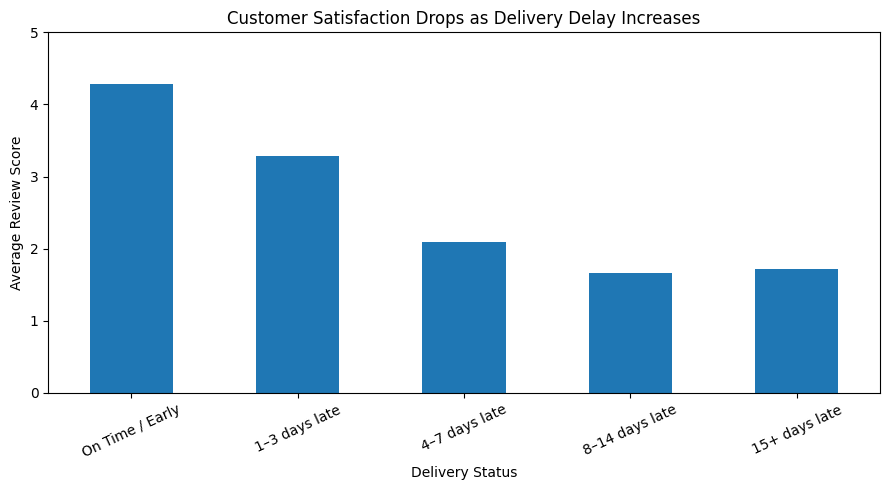

In [222]:
import matplotlib.pyplot as plt

delay_review = (
    delivery_reviews
    .groupby('delay_group', observed=True)['review_score']
    .mean()
)

plt.figure(figsize=(9, 5))
delay_review.plot(kind='bar')

plt.title('Customer Satisfaction Drops as Delivery Delay Increases')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.xticks(rotation=25)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

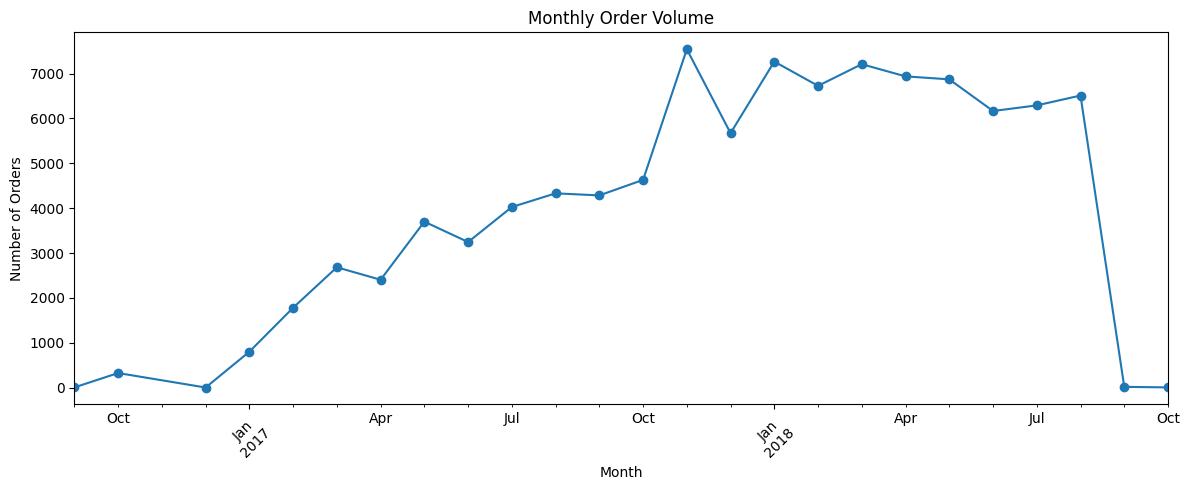

In [223]:
monthly_orders = (
    orders.assign(
        month=orders['order_purchase_timestamp'].dt.to_period('M')
    )
    .groupby('month')['order_id']
    .nunique()
)

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o')

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

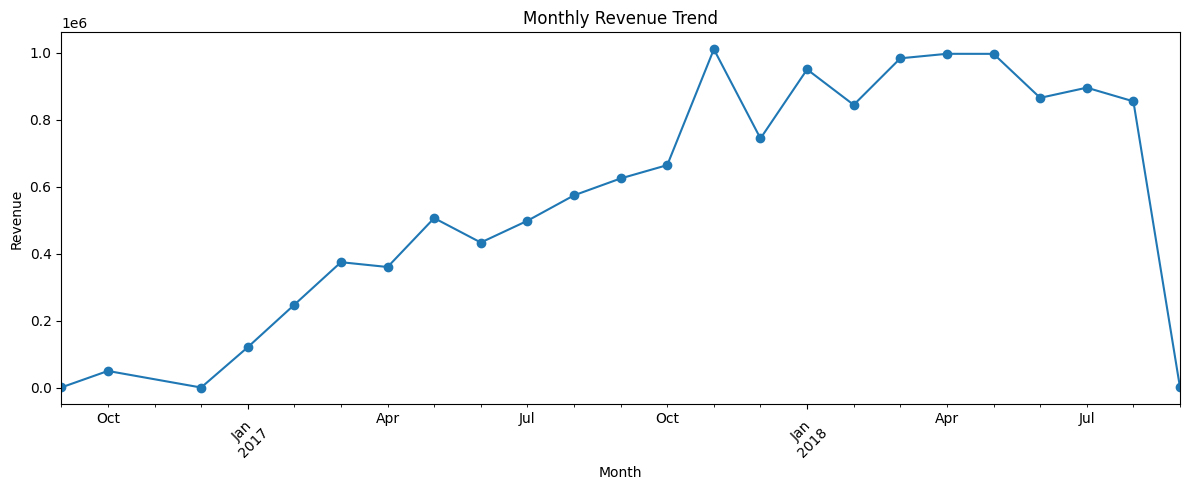

In [224]:
monthly_revenue = (
    order_items.assign(
        month=orders.set_index('order_id')
        .loc[order_items['order_id'], 'order_purchase_timestamp']
        .dt.to_period('M').values
    )
    .groupby('month')['price']
    .sum()
)

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

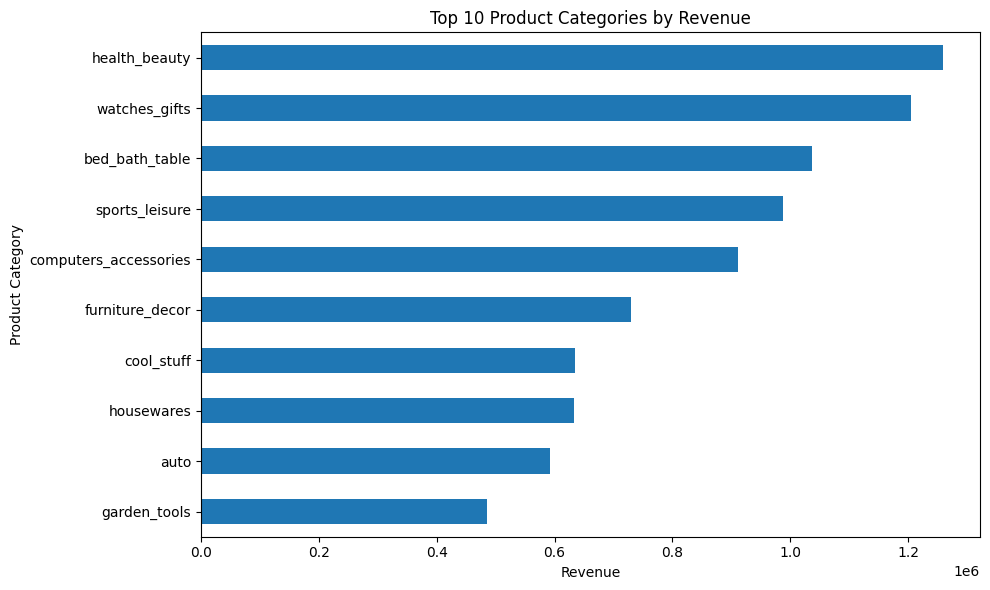

In [225]:
top_categories = (
    category_summary
    .head(10)
    .sort_values('sales_value')
)

plt.figure(figsize=(10, 6))
top_categories['sales_value'].plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

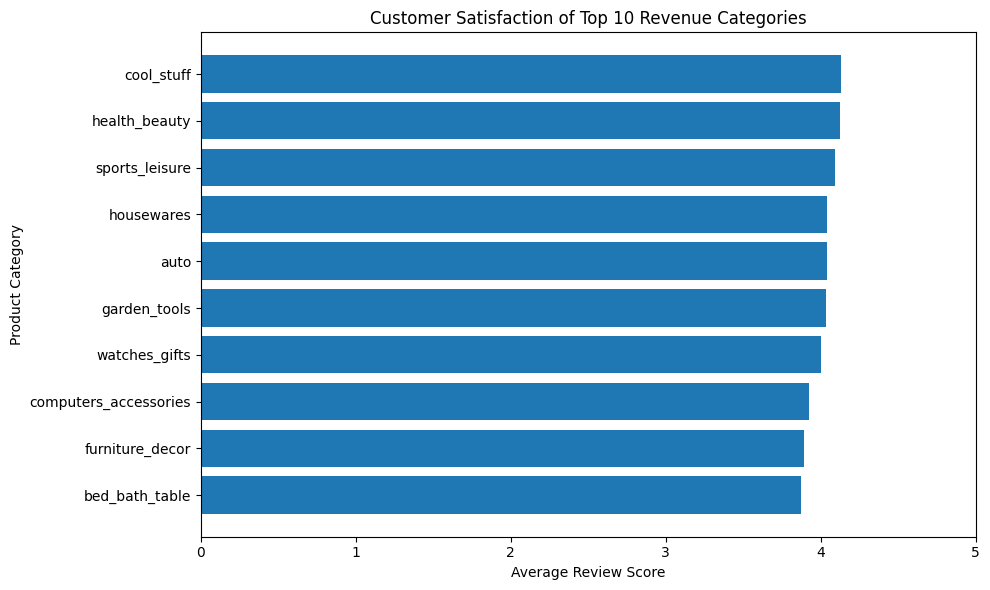

In [226]:
top_categories_review = (
    category_summary
    .sort_values('sales_value', ascending=False)
    .head(10)
    .sort_values('avg_review_score')
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_categories_review.index,
    top_categories_review['avg_review_score']
)

plt.title('Customer Satisfaction of Top 10 Revenue Categories')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

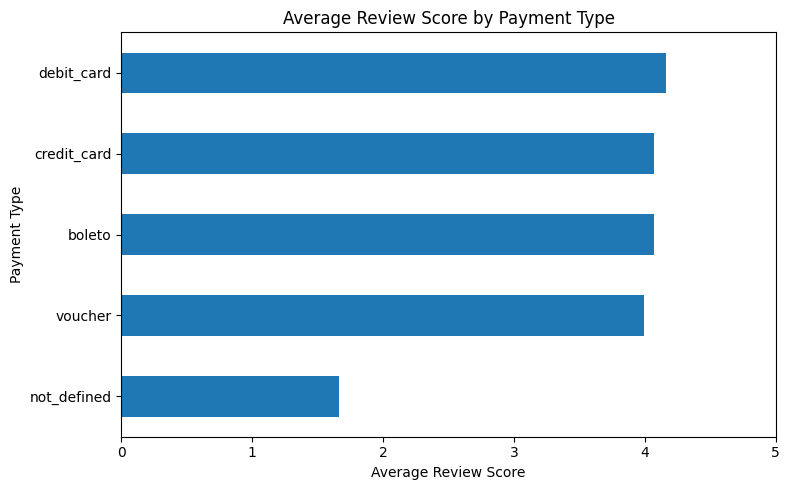

In [227]:
payment_review_summary = (
    payment_reviews.groupby('payment_type')['review_score']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
payment_review_summary.plot(kind='barh')

plt.title('Average Review Score by Payment Type')
plt.xlabel('Average Review Score')
plt.ylabel('Payment Type')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [228]:
print("===== OLIST MARKETPLACE KEY KPIs =====")
print(f"Total Orders: {orders['order_id'].nunique():,}")
print(f"Delivered Orders: {len(delivered_orders):,}")
print(f"Late Delivered Orders: {(delivery_reviews['delivery_delay_days'] > 0).sum():,}")
print(f"Late Delivery Rate: {(delivery_reviews['delivery_delay_days'] > 0).mean() * 100:.2f}%")
print(f"Average Delivery Time: {delivered_orders['delivery_days'].mean():.2f} days")
print(f"Average Review Score: {delivery_reviews['review_score'].mean():.2f}")
print(f"Low Review Rate (1–2): {delivery_reviews['low_review'].mean() * 100:.2f}%")

===== OLIST MARKETPLACE KEY KPIs =====
Total Orders: 99,441
Delivered Orders: 96,470
Late Delivered Orders: 6,534
Late Delivery Rate: 6.77%
Average Delivery Time: 12.09 days
Average Review Score: 4.14
Low Review Rate (1–2): 13.12%


In [229]:
# Display the shape of each dataset

for sheet in excel_file.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    print(f"{sheet}: {df.shape}")

orders: (99441, 8)
order_items: (112650, 6)
order_payments: (103886, 5)
order_reviews: (100000, 7)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


## 2. Data Cleaning

Before analysis, the data was checked for missing values, duplicate records, inconsistent date formats, and relationships between the different tables.

The following cleaning steps were performed:

- Converted order date columns to datetime format
- Focused delivery-time analysis on delivered orders with a valid delivery date
- Removed duplicate review records by aggregating multiple reviews for the same order
- Translated product categories into English
- Filled unavailable product category names as `Unknown`
- Created delivery delay and delivery status variables
- Created a low-review indicator for review scores of 1 or 2
- Applied appropriate aggregation when combining order items, payments, reviews, products, and sellers

In [230]:
# Missing values in the datasets already loaded

print("ORDERS")
print(orders.isnull().sum()[orders.isnull().sum() > 0])

print("\nREVIEWS")
print(reviews.isnull().sum()[reviews.isnull().sum() > 0])

print("\nPRODUCTS")
print(products.isnull().sum()[products.isnull().sum() > 0])

print("\nORDER ITEMS")
print(order_items.isnull().sum()[order_items.isnull().sum() > 0])

print("\nPAYMENTS")
print(order_payments.isnull().sum()[order_payments.isnull().sum() > 0])

print("\nSELLERS")
print(sellers.isnull().sum()[sellers.isnull().sum() > 0])

ORDERS
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

REVIEWS
review_comment_title      88285
review_comment_message    58247
dtype: int64

PRODUCTS
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

ORDER ITEMS
Series([], dtype: int64)

PAYMENTS
Series([], dtype: int64)

SELLERS
Series([], dtype: int64)


### Missing Value Summary

The missing-value analysis showed that most missing values occur in optional or condition-specific fields.

- Order delivery timestamps contain missing values mainly because not all orders reached the corresponding delivery stage.
- Review comments contain many missing values, but review scores are available and were therefore retained for satisfaction analysis.
- Some product attributes and category names are missing; unavailable category names were handled as `Unknown`.
- Order items, payment records, and seller data contain no missing values in the fields used for analysis.

No unnecessary imputation was performed, as missing values were handled according to their business meaning.

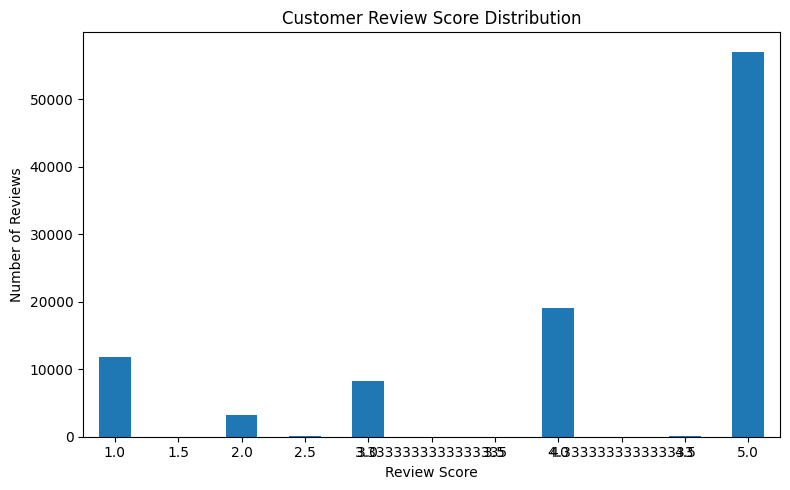

In [231]:
review_distribution = (
    reviews_clean['review_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
review_distribution.plot(kind='bar')

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

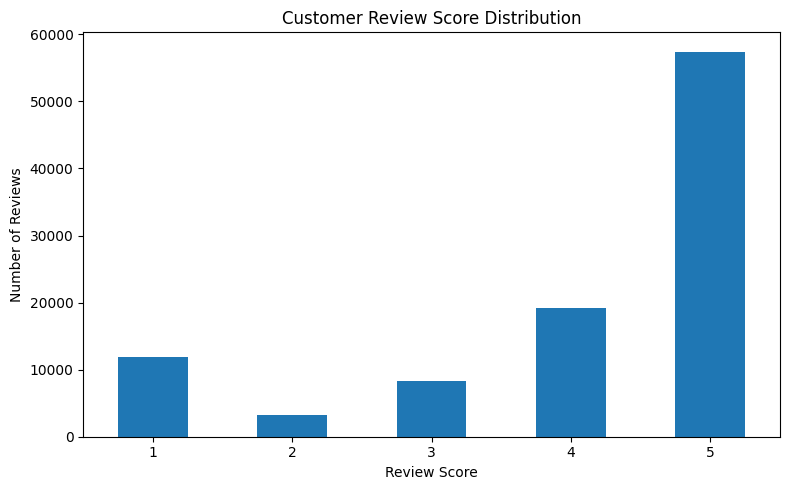

In [232]:
review_distribution = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
review_distribution.plot(kind='bar')

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

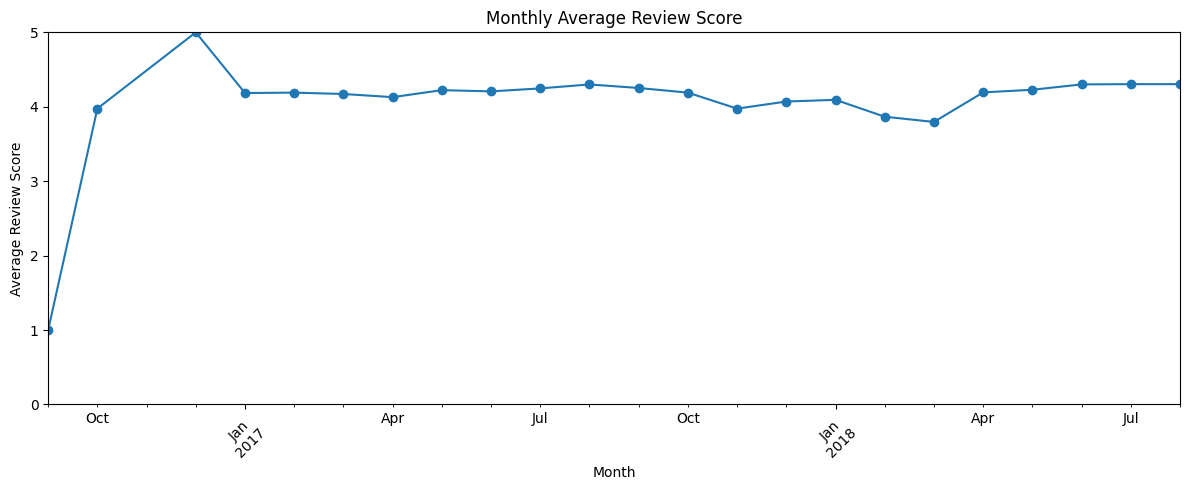

In [233]:
monthly_review = (
    delivery_reviews.assign(
        month=delivery_reviews['order_purchase_timestamp'].dt.to_period('M')
    )
    .groupby('month')['review_score']
    .mean()
)

plt.figure(figsize=(12, 5))
monthly_review.plot(kind='line', marker='o')

plt.title('Monthly Average Review Score')
plt.xlabel('Month')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

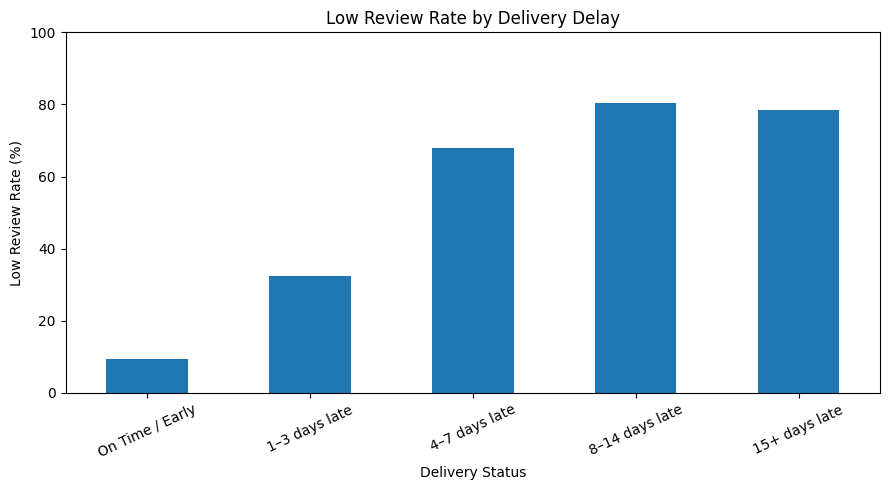

In [234]:
low_review_by_delay = (
    delivery_reviews
    .groupby('delay_group', observed=True)['low_review']
    .mean() * 100
)

plt.figure(figsize=(9, 5))
low_review_by_delay.plot(kind='bar')

plt.title('Low Review Rate by Delivery Delay')
plt.xlabel('Delivery Status')
plt.ylabel('Low Review Rate (%)')
plt.xticks(rotation=25)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Key Finding: Delivery Delay and Customer Dissatisfaction

Delivery delay shows a strong association with customer dissatisfaction.

- Only about 9.5% of on-time or early deliveries received a low review score (1–2).
- This increased to about 32.5% for orders delivered 1–3 days late.
- For orders delivered 4–7 days late, the low-review rate increased to about 68%.
- The rate reached around 80% for orders delayed by 8–14 days.

This indicates that delivery delay is one of the strongest factors associated with low customer satisfaction.

**Note:** This analysis shows association, not causation.

In [235]:
seller_performance = (
    seller_reviews.groupby(
        ['seller_id', 'seller_city', 'seller_state']
    )
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
)

seller_performance = seller_performance[
    seller_performance['item_count'] >= 50
].sort_values('avg_review_score')

seller_performance.head(10)

,,,item_count,avg_review_score,low_review_rate
seller_id,seller_city,seller_state,,,
1ca7077d890b907f89be8c954a02686a,santana de parnaiba,SP,137,2.189781,0.656934
2eb70248d66e0e3ef83659f71b244378,campinas,SP,212,2.681604,0.509434
54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,86,2.825581,0.488372
972d0f9cf61b499a4812cf0bfa3ad3c4,brusque,SC,88,2.920455,0.454545
602044f2c16190c2c6e45eb35c2e21cb,ibitinga,SP,57,2.929825,0.438596
a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,106,2.952830,0.433962
2a1348e9addc1af5aaa619b1a3679d6b,belo horizonte,MG,55,2.963636,0.418182
8e6d7754bc7e0f22c96d255ebda59eba,sao jose dos campos,SP,130,2.973077,0.453846
bbad7e518d7af88a0897397ffdca1979,sao paulo,SP,85,3.011765,0.458824


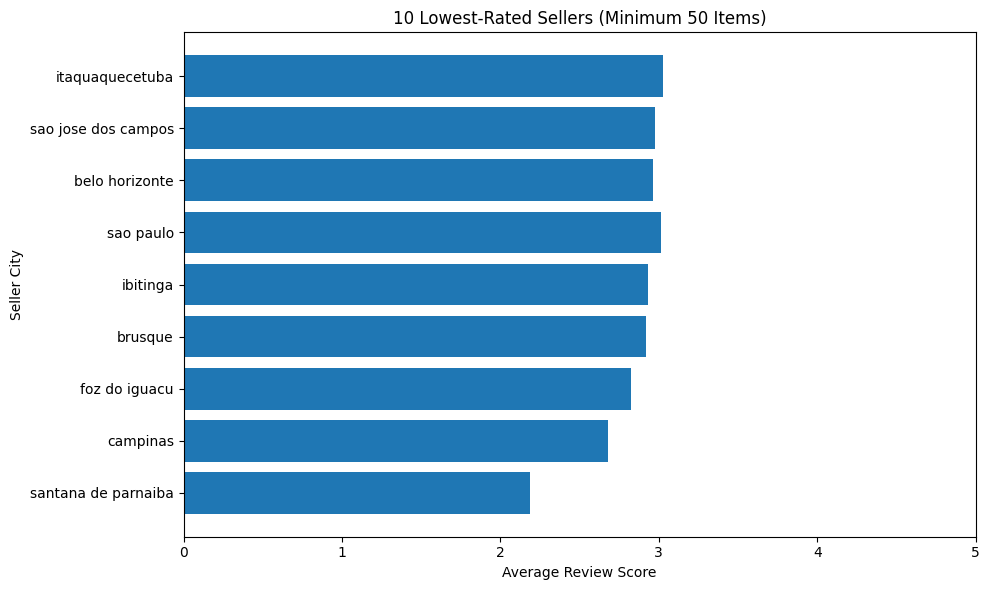

In [236]:
top_bad_sellers = seller_performance.head(10).sort_values('avg_review_score')

plt.figure(figsize=(10, 6))
plt.barh(
    top_bad_sellers.index.get_level_values('seller_city'),
    top_bad_sellers['avg_review_score']
)

plt.title('10 Lowest-Rated Sellers (Minimum 50 Items)')
plt.xlabel('Average Review Score')
plt.ylabel('Seller City')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

### Key Finding: Seller-Level Customer Satisfaction

Seller performance varies considerably across the marketplace.

Among sellers with at least 50 items, some sellers show substantially lower average review scores, with the lowest-rated seller having an average score of around 2.19 and a low-review rate of about 65.7%.

This suggests that seller-level performance may contribute to customer dissatisfaction.

However, seller ratings should be interpreted together with delivery performance, freight cost, product category, and order volume before identifying specific root causes.

In [237]:
state_performance = (
    seller_reviews.groupby('seller_state')
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
)

state_performance = state_performance[
    state_performance['item_count'] >= 100
].sort_values('avg_review_score')

state_performance

,item_count,avg_review_score,low_review_rate
seller_state,,,
MA,405,3.958025,0.175309
ES,372,3.970430,0.172043
SP,80342,3.988831,0.170820
DF,899,4.031146,0.160178
PR,8671,4.060316,0.157537
SC,4075,4.078773,0.152638
RJ,4818,4.080324,0.160025
MG,8827,4.085533,0.146029
BA,643,4.086314,0.132193


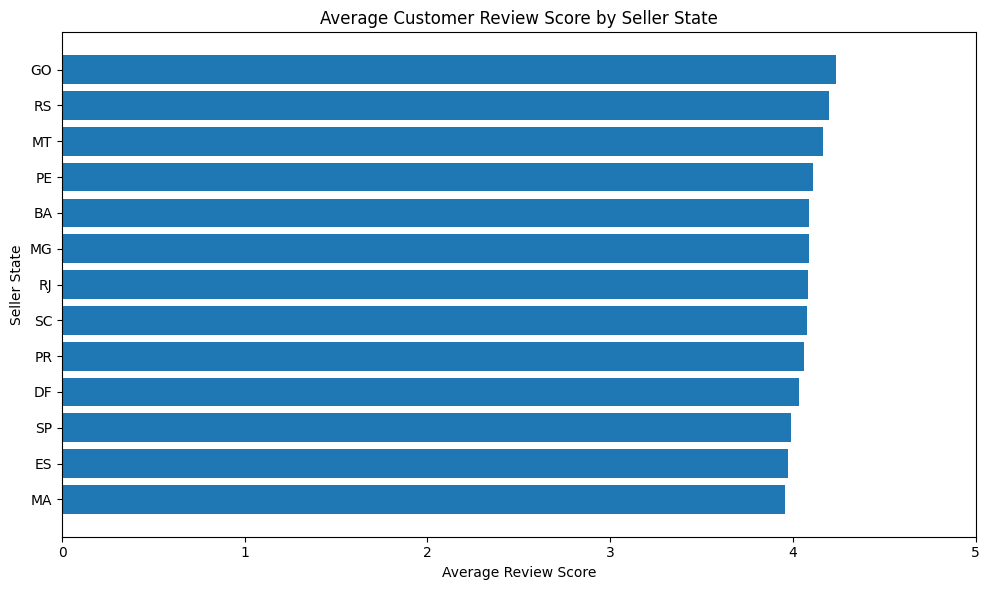

In [238]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_performance.index,
    state_performance['avg_review_score']
)

plt.title('Average Customer Review Score by Seller State')
plt.xlabel('Average Review Score')
plt.ylabel('Seller State')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

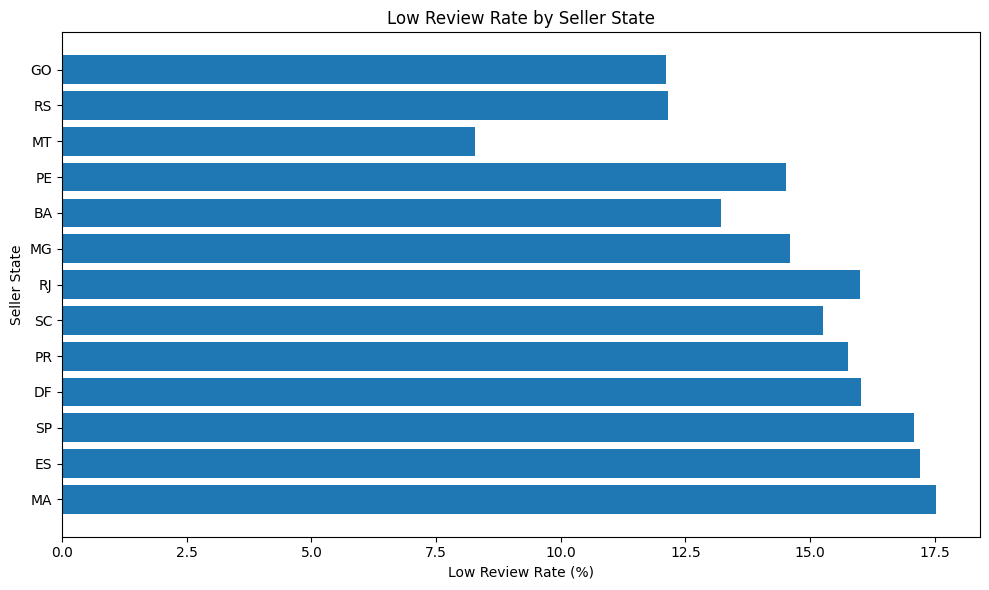

In [239]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_performance.index,
    state_performance['low_review_rate'] * 100
)

plt.title('Low Review Rate by Seller State')
plt.xlabel('Low Review Rate (%)')
plt.ylabel('Seller State')

plt.tight_layout()
plt.show()

### Key Finding: Geographic Variation in Seller Performance

Customer satisfaction varies across seller states.

Among states with at least 100 reviewed items, Maranhão (MA), Espírito Santo (ES), and São Paulo (SP) show relatively higher low-review rates, while Mato Grosso (MT), Goiás (GO), and Rio Grande do Sul (RS) show lower rates.

This suggests that seller location may be associated with differences in customer satisfaction.

However, seller-state patterns may also reflect differences in delivery routes, product categories, seller mix, and other operational factors. Therefore, seller geography should be treated as a secondary factor rather than a direct cause of dissatisfaction.

In [240]:
state_delivery = (
    seller_delivery.groupby('seller_state')
    .agg(
        item_count=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        avg_delivery_delay=('delivery_delay_days', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
)

state_delivery = state_delivery[
    state_delivery['item_count'] >= 100
].sort_values('avg_delivery_delay', ascending=False)

state_delivery

,item_count,avg_review_score,avg_delivery_delay,low_review_rate
seller_state,,,,
MA,402,3.980100,-11.263682,0.169154
SP,78598,4.038088,-11.298354,0.157587
RJ,4685,4.146852,-12.479829,0.141942
BA,624,4.154647,-12.807692,0.113782
DF,883,4.065685,-13.184598,0.150623
ES,364,4.035714,-13.359890,0.153846
MG,8601,4.146320,-13.471108,0.129869
SC,4000,4.116750,-14.198250,0.142250
PR,8487,4.114646,-14.234005,0.142571


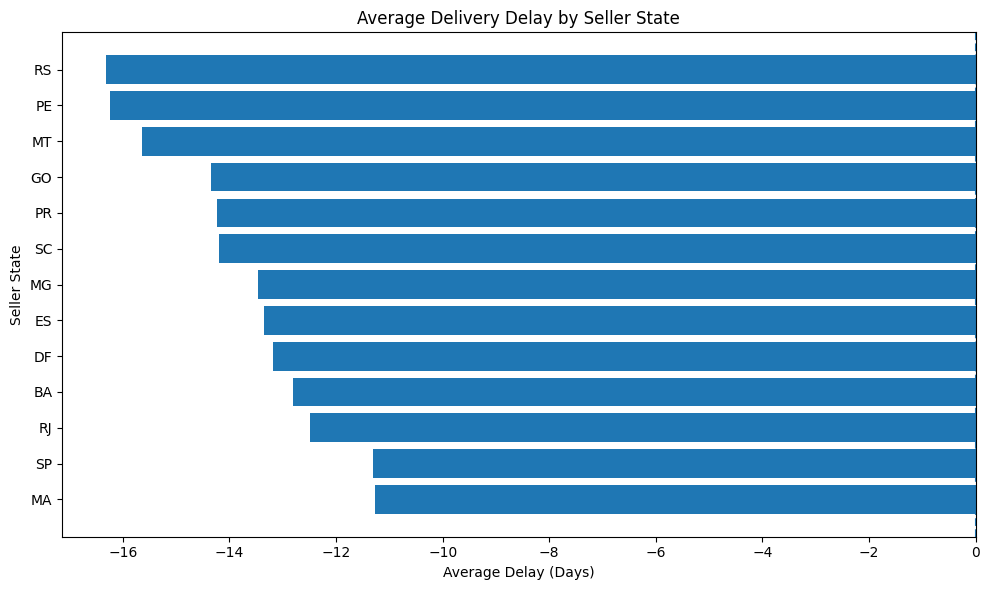

In [241]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_delivery.index,
    state_delivery['avg_delivery_delay']
)

plt.title('Average Delivery Delay by Seller State')
plt.xlabel('Average Delay (Days)')
plt.ylabel('Seller State')

plt.axvline(0, linestyle='--')

plt.tight_layout()
plt.show()

### Key Finding: Seller Geography vs Delivery Performance

Seller states show noticeable differences in customer satisfaction, but average delivery timing alone does not explain these differences.

All major seller states in the analysis have a negative average delivery delay, meaning orders were delivered earlier than the estimated date on average.

This suggests that seller geography may capture other factors such as seller quality, product mix, customer expectations, or operational differences.

Therefore, delivery delay remains a strong order-level factor, while seller geography should be considered a secondary factor requiring further investigation.

In [242]:
category_sales = (
    items_products.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
)

category_sales.head(10)

,price
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


In [243]:
category_review = (
    items_products.merge(
        reviews_clean,
        on='order_id',
        how='left'
    )
    .groupby('product_category_name_english')['review_score']
    .mean()
    .sort_values(ascending=False)
)

category_review.head(10)

,review_score
product_category_name_english,
cds_dvds_musicals,4.642857
fashion_childrens_clothes,4.500000
books_general_interest,4.439421
books_imported,4.400000
costruction_tools_tools,4.359223
books_technical,4.333333
luggage_accessories,4.309524
small_appliances_home_oven_and_coffee,4.302632
food_drink,4.300360


In [244]:
category_summary = pd.concat(
    [
        category_sales.rename('sales_value'),
        category_review.rename('avg_review_score'),
        items_products['product_category_name_english']
        .value_counts()
        .rename('item_count')
    ],
    axis=1
).sort_values('sales_value', ascending=False)

category_summary.head(15)

,sales_value,avg_review_score,item_count
product_category_name_english,,,
health_beauty,1258681.34,4.123354,9670
watches_gifts,1205005.68,4.001669,5991
bed_bath_table,1036988.68,3.873729,11115
sports_leisure,988048.97,4.092293,8641
computers_accessories,911954.32,3.922256,7827
furniture_decor,729762.49,3.891049,8334
cool_stuff,635290.85,4.131586,3796
housewares,632248.66,4.039632,6964
auto,592720.11,4.038961,4235


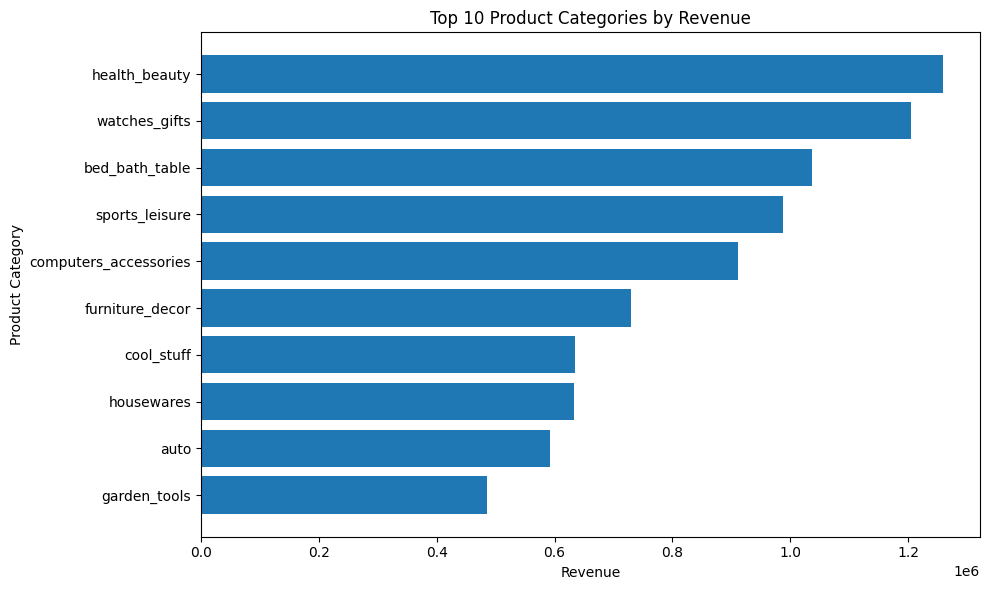

In [245]:
top_categories = (
    category_summary
    .head(10)
    .sort_values('sales_value')
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories.index,
    top_categories['sales_value']
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### Key Finding: Product Category Performance

Revenue is concentrated in a few major product categories.

Health & Beauty generated the highest revenue at approximately 1.26 million, followed by Watches & Gifts at 1.21 million and Bed & Bath Table at 1.04 million.

High revenue does not always correspond to higher customer satisfaction. For example, Bed & Bath Table has high sales volume but a relatively lower average review score of about 3.87.

This indicates that marketplace performance should be evaluated using both business performance and customer satisfaction metrics.

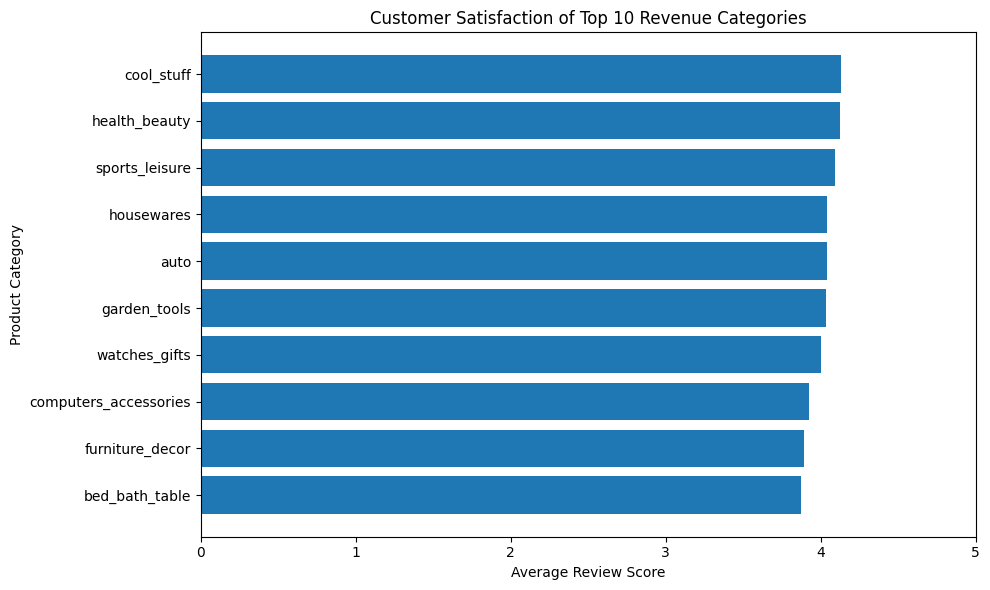

In [246]:
top_categories_review = (
    category_summary
    .sort_values('sales_value', ascending=False)
    .head(10)
    .sort_values('avg_review_score')
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories_review.index,
    top_categories_review['avg_review_score']
)

plt.title('Customer Satisfaction of Top 10 Revenue Categories')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()


### Key Finding: Revenue vs Customer Satisfaction

High-revenue product categories do not always have the highest customer satisfaction.

Cool Stuff and Health & Beauty have both strong revenue performance and average review scores above 4.1.

In contrast, Bed & Bath Table generates more than 1 million in sales but has an average review score of only about 3.87, the lowest among the top 10 revenue categories.

This suggests that high-revenue categories with relatively lower satisfaction should be prioritized for further investigation.

In [247]:
payment_review_summary = (
    payment_reviews
    .groupby('payment_type')['review_score']
    .mean()
    .sort_values()
)

payment_review_summary

,review_score
payment_type,
not_defined,1.666667
voucher,3.993045
boleto,4.071927
credit_card,4.072372
debit_card,4.158600


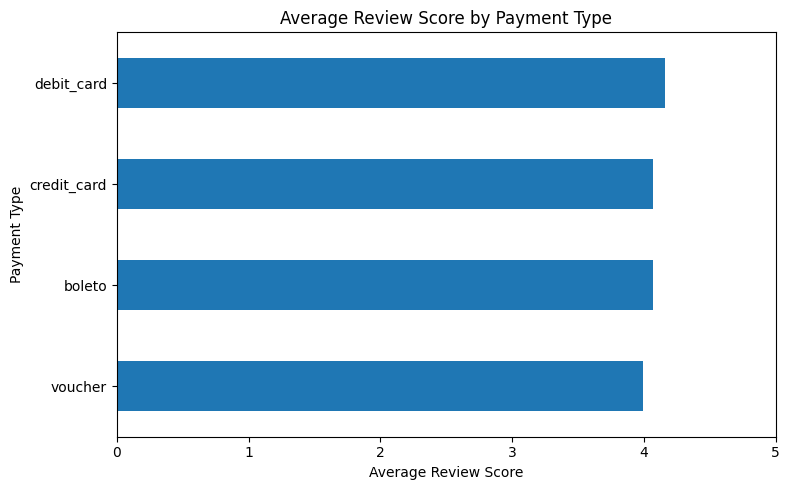

In [248]:
id="paymentchart1"
payment_review_summary = payment_review_summary.drop('not_defined')

plt.figure(figsize=(8, 5))
payment_review_summary.plot(kind='barh')

plt.title('Average Review Score by Payment Type')
plt.xlabel('Average Review Score')
plt.ylabel('Payment Type')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [249]:
installment_review = (
    payment_reviews
    .groupby('installment_group')['review_score']
    .mean()
)

installment_review

/tmp/ipykernel_4461/3281983686.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('installment_group')['review_score']


,review_score
installment_group,
1 installment,4.096889
2–3 installments,4.068921
4–6 installments,4.047538
7+ installments,3.978332


### Key Finding: Payment Behavior and Customer Satisfaction

Customer satisfaction is relatively similar across different payment methods.

Debit card users have the highest average review score at about 4.16, while voucher users have the lowest among the main payment methods at about 3.99.

Review scores also decrease slightly as the number of installments increases, from about 4.10 for one installment to about 3.98 for 7+ installments.

However, these differences are relatively small compared with the strong relationship observed between delivery delays and low review scores.

Therefore, payment behavior appears to be a secondary factor rather than a primary driver of dissatisfaction.

In [250]:
factor_summary = pd.DataFrame({
    'Factor': [
        'On Time / Early Delivery',
        'Late Delivery',
        '1 Installment',
        '2–3 Installments',
        '4–6 Installments',
        '7+ Installments'
    ],
    'Average Review Score': [
        delivery_reviews.loc[
            delivery_reviews['delivery_delay_days'] <= 0,
            'review_score'
        ].mean(),
        delivery_reviews.loc[
            delivery_reviews['delivery_delay_days'] > 0,
            'review_score'
        ].mean(),
        installment_review['1 installment'],
        installment_review['2–3 installments'],
        installment_review['4–6 installments'],
        installment_review['7+ installments']
    ]
})

factor_summary

,Factor,Average Review Score
0,On Time / Early Delivery,4.279729
1,Late Delivery,2.256581
2,1 Installment,4.096889
3,2–3 Installments,4.068921
4,4–6 Installments,4.047538
5,7+ Installments,3.978332


## 3. Root Cause Analysis

The analysis indicates that delivery performance is the strongest factor associated with customer dissatisfaction.

### Primary Contributor
**Delivery delay**

- On-time or early deliveries have an average review score of about 4.28.
- Late deliveries have an average review score of about 2.26.
- The low-review rate rises sharply as delivery delays increase.

### Secondary Contributors
**Seller performance, seller geography, and product category**

These factors show noticeable differences in customer satisfaction, but they do not consistently explain dissatisfaction on their own.

**Payment behavior** appears to have a weaker relationship with satisfaction, as review scores across payment types and installment groups remain relatively close.

### Overall Conclusion

Delivery delay should be treated as the primary area for improvement, while seller performance, product categories, and geographic patterns should be investigated as secondary contributors.

**Important:** These findings show statistical association and should not be interpreted as proof of causation.

In [251]:
print("===== OLIST MARKETPLACE FINAL KPIs =====")
print(f"Total Orders: {orders['order_id'].nunique():,}")
print(f"Delivered Orders: {len(delivered_orders):,}")
print(f"Late Delivered Orders: {(delivery_reviews['delivery_delay_days'] > 0).sum():,}")
print(f"Late Delivery Rate: {(delivery_reviews['delivery_delay_days'] > 0).mean() * 100:.2f}%")
print(f"Average Delivery Time: {delivered_orders['delivery_days'].mean():.2f} days")
print(f"Average Review Score: {delivery_reviews['review_score'].mean():.2f}")
print(f"Low Review Rate (1–2): {delivery_reviews['low_review'].mean() * 100:.2f}%")

===== OLIST MARKETPLACE FINAL KPIs =====
Total Orders: 99,441
Delivered Orders: 96,470
Late Delivered Orders: 6,534
Late Delivery Rate: 6.77%
Average Delivery Time: 12.09 days
Average Review Score: 4.14
Low Review Rate (1–2): 13.12%


## 4. Final Conclusion

The analysis shows that the Olist marketplace performed strongly in terms of order volume and overall customer satisfaction, with 99,441 total orders and an average review score of 4.14.

The most important finding is the strong association between delivery performance and customer satisfaction. Although 93.23% of delivered orders were on time or early, late deliveries had a much lower average review score (2.26) compared with on-time or early deliveries (4.28).

Product categories and seller performance also show meaningful differences in customer satisfaction. Some high-revenue categories, such as Bed & Bath Table, have relatively lower review scores and may require further investigation.

Payment methods and installment behavior show comparatively smaller differences in customer satisfaction.

### Business Recommendations

1. **Prioritize delivery reliability**
   - Identify orders at risk of being late.
   - Improve delivery monitoring and exception handling.

2. **Investigate low-performing sellers**
   - Review sellers with consistently low satisfaction and meaningful order volumes.
   - Examine their product mix, delivery performance, and customer feedback.

3. **Improve high-revenue, lower-satisfaction categories**
   - Investigate product quality, descriptions, packaging, and delivery experience.

4. **Monitor customer satisfaction continuously**
   - Track review scores and low-review rates alongside operational KPIs.

### Final Takeaway

**Delivery performance is the strongest factor associated with customer dissatisfaction in this analysis. Improving delivery reliability should therefore be a primary marketplace improvement priority, while seller, category, and geographic patterns should be investigated as secondary contributors.**

In [252]:
print("orders:", orders.shape)
print("reviews_clean:", reviews_clean.shape)
print("items_products:", items_products.shape)
print("sellers:", sellers.shape)
print("order_payments:", order_payments.shape)
print("customers:", customers.shape if 'customers' in globals() else "NOT LOADED")

orders: (99441, 8)
reviews_clean: (99441, 2)
items_products: (112650, 7)
sellers: (3095, 4)
order_payments: (103886, 5)
customers: NOT LOADED


In [253]:
customers = pd.read_excel(
    file_path,
    sheet_name="customers"
)

print("Customers:", customers.shape)
print(customers.columns.tolist())

Customers: (99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [254]:
master_orders = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

print("Master orders shape:", master_orders.shape)
print(master_orders.columns.tolist())

Master orders shape: (99441, 12)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [255]:
master_orders = master_orders.merge(
    reviews_clean,
    on='order_id',
    how='left'
)

master_orders['low_review'] = master_orders['review_score'] <= 2

print("Master orders shape:", master_orders.shape)
print(master_orders.columns.tolist())
print("Duplicate order IDs:", master_orders['order_id'].duplicated().sum())

Master orders shape: (99441, 14)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'low_review']
Duplicate order IDs: 0


In [256]:
order_items_summary = (
    items_products.groupby('order_id')
    .agg(
        total_item_value=('price', 'sum'),
        total_freight_value=('freight_value', 'sum'),
        item_count=('order_item_id', 'count'),
        product_count=('product_id', 'nunique'),
        seller_count=('seller_id', 'nunique')
    )
    .reset_index()
)

print("Order items summary:", order_items_summary.shape)
print(order_items_summary.head())

Order items summary: (98666, 6)
                           order_id  total_item_value  total_freight_value  \
0  00010242fe8c5a6d1ba2dd792cb16214             58.90                13.29   
1  00018f77f2f0320c557190d7a144bdd3            239.90                19.93   
2  000229ec398224ef6ca0657da4fc703e            199.00                17.87   
3  00024acbcdf0a6daa1e931b038114c75             12.99                12.79   
4  00042b26cf59d7ce69dfabb4e55b4fd9            199.90                18.14   

   item_count  product_count  seller_count  
0           1              1             1  
1           1              1             1  
2           1              1             1  
3           1              1             1  
4           1              1             1  


In [257]:
# Find the highest-value category for each order
category_order = (
    items_products
    .groupby(['order_id', 'product_category_name_english'])['price']
    .sum()
    .reset_index()
)

primary_category = (
    category_order
    .sort_values(['order_id', 'price'], ascending=[True, False])
    .drop_duplicates('order_id')
    [['order_id', 'product_category_name_english']]
    .rename(columns={
        'product_category_name_english': 'primary_category'
    })
)

print("Primary category shape:", primary_category.shape)
print(primary_category.head())

Primary category shape: (98666, 2)
                           order_id primary_category
0  00010242fe8c5a6d1ba2dd792cb16214       cool_stuff
1  00018f77f2f0320c557190d7a144bdd3         pet_shop
2  000229ec398224ef6ca0657da4fc703e  furniture_decor
3  00024acbcdf0a6daa1e931b038114c75        perfumery
4  00042b26cf59d7ce69dfabb4e55b4fd9     garden_tools


In [258]:
master_orders = master_orders.merge(
    order_items_summary,
    on='order_id',
    how='left'
)

master_orders = master_orders.merge(
    primary_category,
    on='order_id',
    how='left'
)

print("Master orders shape:", master_orders.shape)
print(master_orders.columns.tolist())
print("Duplicate order IDs:", master_orders['order_id'].duplicated().sum())

Master orders shape: (99441, 20)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'low_review', 'total_item_value', 'total_freight_value', 'item_count', 'product_count', 'seller_count', 'primary_category']
Duplicate order IDs: 0


In [259]:
payment_summary = (
    order_payments
    .groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        payment_count=('payment_type', 'count'),
        max_installments=('payment_installments', 'max')
    )
    .reset_index()
)

# Main payment type for each order
payment_type_summary = (
    order_payments
    .groupby(['order_id', 'payment_type'])['payment_value']
    .sum()
    .reset_index()
)

primary_payment = (
    payment_type_summary
    .sort_values(['order_id', 'payment_value'], ascending=[True, False])
    .drop_duplicates('order_id')
    [['order_id', 'payment_type']]
    .rename(columns={'payment_type': 'primary_payment_type'})
)

payment_summary = payment_summary.merge(
    primary_payment,
    on='order_id',
    how='left'
)

print("Payment summary:", payment_summary.shape)
print(payment_summary.head())

Payment summary: (99440, 5)
                           order_id  total_payment_value  payment_count  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19              1   
1  00018f77f2f0320c557190d7a144bdd3               259.83              1   
2  000229ec398224ef6ca0657da4fc703e               216.87              1   
3  00024acbcdf0a6daa1e931b038114c75                25.78              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9               218.04              1   

   max_installments primary_payment_type  
0                 2          credit_card  
1                 3          credit_card  
2                 5          credit_card  
3                 2          credit_card  
4                 3          credit_card  


In [260]:
master_orders = master_orders.merge(
    payment_summary,
    on='order_id',
    how='left'
)

print("Master orders shape:", master_orders.shape)
print(master_orders.columns.tolist())
print("Duplicate order IDs:", master_orders['order_id'].duplicated().sum())

Master orders shape: (99441, 24)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'low_review', 'total_item_value', 'total_freight_value', 'item_count', 'product_count', 'seller_count', 'primary_category', 'total_payment_value', 'payment_count', 'max_installments', 'primary_payment_type']
Duplicate order IDs: 0


In [261]:
# Delivery time in days
master_orders['delivery_days'] = (
    master_orders['order_delivered_customer_date']
    - master_orders['order_purchase_timestamp']
).dt.days

# Difference from estimated delivery date
master_orders['delivery_delay_days'] = (
    master_orders['order_delivered_customer_date']
    - master_orders['order_estimated_delivery_date']
).dt.days

# Delivered flag
master_orders['is_delivered'] = (
    master_orders['order_status'] == 'delivered'
)

# Delivery status
master_orders['delivery_status'] = master_orders['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0
    else 'On Time / Early' if pd.notna(x)
    else 'Not Delivered'
)

print("Master orders shape:", master_orders.shape)
print(master_orders[['delivery_days',
                     'delivery_delay_days',
                     'is_delivered',
                     'delivery_status']].head())

print("\nDelivery status:")
print(master_orders['delivery_status'].value_counts())

Master orders shape: (99441, 28)
   delivery_days  delivery_delay_days  is_delivered  delivery_status
0            8.0                 -8.0          True  On Time / Early
1           13.0                 -6.0          True  On Time / Early
2            9.0                -18.0          True  On Time / Early
3           13.0                -13.0          True  On Time / Early
4            2.0                -10.0          True  On Time / Early

Delivery status:
delivery_status
On Time / Early    89941
Late                6535
Not Delivered       2965
Name: count, dtype: int64


In [262]:
master_orders['order_total_value'] = (
    master_orders['total_item_value'].fillna(0)
    + master_orders['total_freight_value'].fillna(0)
)

print("Final dataset shape:", master_orders.shape)
print(master_orders[['order_id',
                     'total_item_value',
                     'total_freight_value',
                     'order_total_value']].head())


Final dataset shape: (99441, 29)
                           order_id  total_item_value  total_freight_value  \
0  e481f51cbdc54678b7cc49136f2d6af7             29.99                 8.72   
1  53cdb2fc8bc7dce0b6741e2150273451            118.70                22.76   
2  47770eb9100c2d0c44946d9cf07ec65d            159.90                19.22   
3  949d5b44dbf5de918fe9c16f97b45f8a             45.00                27.20   
4  ad21c59c0840e6cb83a9ceb5573f8159             19.90                 8.72   

   order_total_value  
0              38.71  
1             141.46  
2             179.12  
3              72.20  
4              28.62  


In [263]:
print("===== FINAL DATASET CHECK =====")

print("Rows:", len(master_orders))
print("Columns:", len(master_orders.columns))
print("Unique Orders:", master_orders['order_id'].nunique())
print("Duplicate Orders:", master_orders['order_id'].duplicated().sum())

print("\nMissing Values:")
print(master_orders.isnull().sum()[master_orders.isnull().sum() > 0])

print("\nData Types:")
print(master_orders.dtypes)

===== FINAL DATASET CHECK =====
Rows: 99441
Columns: 29
Unique Orders: 99441
Duplicate Orders: 0

Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
total_item_value                  775
total_freight_value               775
item_count                        775
product_count                     775
seller_count                      775
primary_category                  775
total_payment_value                 1
payment_count                       1
max_installments                    1
primary_payment_type                1
delivery_days                    2965
delivery_delay_days              2965
dtype: int64

Data Types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
or

In [264]:
# Export final Power BI dataset
output_path = '/content/olist_powerbi_master.csv'

master_orders.to_csv(
    output_path,
    index=False
)

print("Saved successfully!")
print("File:", output_path)
print("Rows:", len(master_orders))
print("Columns:", len(master_orders.columns))

Saved successfully!
File: /content/olist_powerbi_master.csv
Rows: 99441
Columns: 29


In [265]:
from google.colab import files
files.download('/content/olist_powerbi_master.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>